# Classification Fine Tuning Process Overview

## Three Stages | Ten Steps

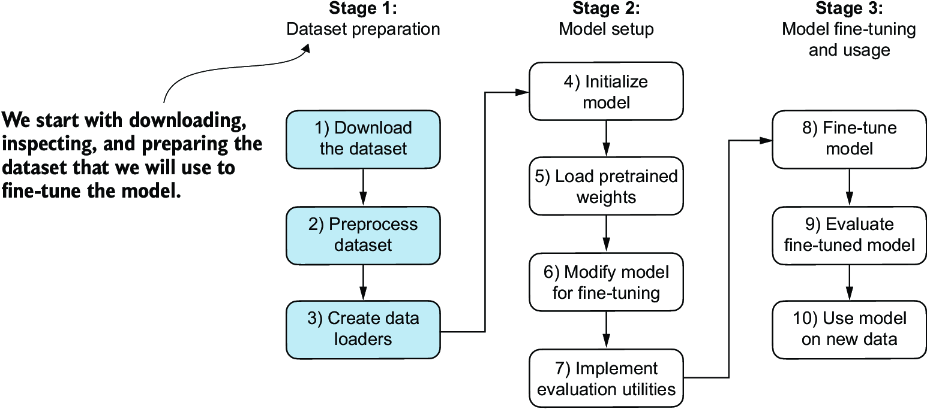

# Stage 1 : Dataset Preparation

## Step 1 : Downloading and unzipping the dataset

In [3]:
import urllib.request
import zipfile
import os
import ssl
from pathlib import Path

url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
zip_path = "chapter6/sms_spam_collection.zip"
extracted_path = "chapter6/sms_spam_collection"
data_file_path = Path(extracted_path) / "SMSSpamCollection.tsv"

def download_and_unzip_spam_data(
        url, zip_path, extracted_path, data_file_path):
    if data_file_path.exists():
        print(f"{data_file_path} already exists. Skipping download "
              "and extraction."
        )
        return

    # Create a custom SSL context that doesn't verify certificates
    ctx = ssl.create_default_context()
    ctx.check_hostname = False
    ctx.verify_mode = ssl.CERT_NONE
    
    with urllib.request.urlopen(url, context=ctx) as response:
        with open(zip_path, "wb") as out_file:
            out_file.write(response.read())

    with zipfile.ZipFile(zip_path, "r") as zip_ref:
        zip_ref.extractall(extracted_path)

    original_file_path = Path(extracted_path) / "SMSSpamCollection"
    os.rename(original_file_path, data_file_path)
    print(f"File downloaded and saved as {data_file_path}")

download_and_unzip_spam_data(url, zip_path, extracted_path, data_file_path)

File downloaded and saved as chapter6/sms_spam_collection/SMSSpamCollection.tsv


## Step 2 : Preprocess Dataset

### Loading into Pandas DataFrame

In [4]:
import pandas as pd
df = pd.read_csv(
    data_file_path, sep="\t", header=None, names=["Label", "Text"]
)
df

,Label,Text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will ü b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [5]:
print(df["Label"].value_counts())

Label
ham     4825
spam     747
Name: count, dtype: int64


### Handling Class Imbalances - Create a Balanced Dataset

In [6]:
def create_balanced_dataset(df):
    num_spam = df[df["Label"] == "spam"].shape[0]
    ham_subset = df[df["Label"] == "ham"].sample(
        num_spam, random_state=123
    )
    balanced_df = pd.concat([
        ham_subset, df[df["Label"] == "spam"]
    ])
    return balanced_df

balanced_df = create_balanced_dataset(df)
print(balanced_df["Label"].value_counts())

Label
ham     747
spam    747
Name: count, dtype: int64


### Convert Class Labels to Binary 0 and 1

In [8]:
balanced_df["Label"] = balanced_df["Label"].map({"ham": 0, "spam": 1})

In [10]:
print(balanced_df["Label"].value_counts())

Label
0    747
1    747
Name: count, dtype: int64


### Split the dataset - 70% for training, 10% for validation, and 20% for testing

In [11]:
def random_split(df, train_frac, validation_frac):

    df = df.sample(
        frac=1, random_state=123
    ).reset_index(drop=True)
    train_end = int(len(df) * train_frac)
    validation_end = train_end + int(len(df) * validation_frac)

    train_df = df[:train_end]
    validation_df = df[train_end:validation_end]
    test_df = df[validation_end:]

    return train_df, validation_df, test_df

train_df, validation_df, test_df = random_split(
    balanced_df, 0.7, 0.1)

In [12]:
train_df.to_csv("chapter6/train.csv", index=None)
validation_df.to_csv("chapter6/validation.csv", index=None)
test_df.to_csv("chapter6/test.csv", index=None)

## Step 3 : Create Dataloaders

### Verify token Id for endoftext token

In [13]:
import tiktoken
tokenizer = tiktoken.get_encoding("gpt2")
print(tokenizer.encode("<|endoftext|>", allowed_special={"<|endoftext|>"}))

[50256]


### Setting Pytorch Dataset Class

In [14]:
import torch
from torch.utils.data import Dataset

class SpamDataset(Dataset):
    
    def __init__(self, 
                 csv_file, 
                 tokenizer, 
                 max_length=None,
                 pad_token_id=50256):
        self.data = pd.read_csv(csv_file)

        self.encoded_texts = [
            tokenizer.encode(text) for text in self.data["Text"]
        ]

        if max_length is None:
            self.max_length = self._longest_encoded_length()
        else:
            self.max_length = max_length

            self.encoded_texts = [
                encoded_text[:self.max_length]
                for encoded_text in self.encoded_texts
            ]

        self.encoded_texts = [
            encoded_text + [pad_token_id] * 
            (self.max_length - len(encoded_text))
            for encoded_text in self.encoded_texts
        ]
        
    def __getitem__(self, index):
        encoded = self.encoded_texts[index]
        label = self.data.iloc[index]["Label"]
        return (
            torch.tensor(encoded, dtype=torch.long),
            torch.tensor(label, dtype=torch.long)
        )

    def __len__(self):
        return len(self.data)

    
    def _longest_encoded_length(self):
        max_length = 0
        for encoded_text in self.encoded_texts:
            encoded_length = len(encoded_text)
            if encoded_length > max_length:
                max_length = encoded_length
        return max_length

### Create Dataset - Training, Validation and Test

In [27]:
train_dataset = SpamDataset(
    csv_file="chapter6/train.csv",
    max_length=None,
    tokenizer=tokenizer
)

val_dataset = SpamDataset(
    csv_file="chapter6/validation.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

test_dataset = SpamDataset(
    csv_file="chapter6/test.csv",
    max_length=train_dataset.max_length,
    tokenizer=tokenizer
)

In [28]:
# Longest Sequence length in the training data
print(test_dataset.max_length)

120


### Create DataLoader - Training, Validation and Test 

In [29]:
from torch.utils.data import DataLoader

num_workers = 0
batch_size = 8
torch.manual_seed(123)

train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    drop_last=True,
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

test_loader = DataLoader(
    dataset=test_dataset,
    batch_size=batch_size,
    num_workers=num_workers,
    drop_last=False,
)

In [30]:
for input_batch, target_batch in train_loader:
    pass # statement is a null operation. It does nothing
    
print("Input batch dimensions:", input_batch.shape)
print("Label batch dimensions", target_batch.shape)

Input batch dimensions: torch.Size([8, 120])
Label batch dimensions torch.Size([8])


In [31]:
print(f"{len(train_loader)} training batches")
print(f"{len(val_loader)} validation batches")
print(f"{len(test_loader)} test batches")

130 training batches
19 validation batches
38 test batches


# Checkpoint # 1

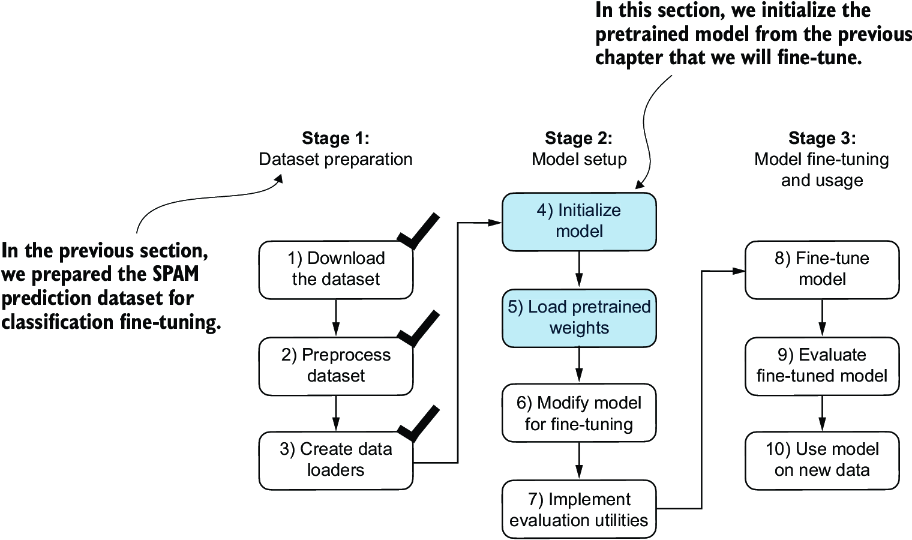

# Stage 2 : Model Setup

## Initialize Model

# Excercises

## Exercise 6.1

`Pad the inputs to the maximum number of tokens the model supports and observe how it affects the predictive performance.`

In [23]:
max_length = 1024

train_dataset = SpamDataset(
    csv_file="chapter6/train.csv",
    max_length=max_length,
    tokenizer=tokenizer
)

val_dataset = SpamDataset(
    csv_file="chapter6/validation.csv",
    max_length=max_length,
    tokenizer=tokenizer
)

test_dataset = SpamDataset(
    csv_file="chapter6/test.csv",
    max_length=max_length,
    tokenizer=tokenizer
)

In [26]:
# Longest Sequence length in the training data
print(val_dataset.max_length)

1024
